In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Task 1 — Data Exploration
- Load the CSV with pandas and print the shape, the first few rows, and df.describe().
- Plot the class distribution (a bar chart of the label column).
- Plot at least two feature histograms (e.g. src_bytes and count) with one histogram per class on the same axes so you can see where normal and attack traﬀic differ.

In [2]:
df = pd.read_csv('../dataset/network_traffic.csv')

In [3]:
df.sample(5)

,duration,src_bytes,dst_bytes,wrong_fragment,hot,logged_in,num_compromised,count,srv_count,serror_rate,same_srv_rate,diff_srv_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,label
5717,0,238,366,0,0,1,0,24,33,0.0,1.00,0.00,91,255,1.00,0
3189,42569,1,0,0,0,0,0,2,2,0.0,1.00,0.00,150,2,0.01,1
5414,0,0,0,0,0,0,0,140,14,1.0,0.10,0.06,255,4,0.02,1
2656,0,202,324,0,0,1,0,11,11,0.0,1.00,0.00,154,255,1.00,0
350,0,0,0,0,0,0,0,192,14,0.0,0.07,0.06,255,14,0.05,1


In [4]:
df.shape

(6000, 16)

In [5]:
df.describe()

,duration,src_bytes,dst_bytes,wrong_fragment,hot,logged_in,num_compromised,count,srv_count,serror_rate,same_srv_rate,diff_srv_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,label
count,6000.000000,6.000000e+03,6.000000e+03,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,413.933000,1.603307e+04,2.951740e+03,0.028333,0.206167,0.385000,0.179667,80.434500,27.572333,0.293578,0.658218,0.060692,180.643333,112.433000,0.519193,0.500000
std,3237.030266,3.049754e+05,7.057366e+04,0.283803,2.120632,0.486636,8.981360,108.869318,70.945265,0.451700,0.438878,0.170613,99.879900,108.894863,0.445222,0.500042
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.100000,0.000000,79.000000,11.000000,0.050000,0.000000
50%,0.000000,4.300000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,15.000000,8.000000,0.000000,1.000000,0.000000,255.000000,60.000000,0.490000,0.500000
75%,0.000000,2.730000e+02,4.550000e+02,0.000000,0.000000,1.000000,0.000000,135.250000,18.000000,1.000000,1.000000,0.060000,255.000000,255.000000,1.000000,1.000000
max,42569.000000,1.698050e+07,5.149533e+06,3.000000,30.000000,1.000000,520.000000,511.000000,511.000000,1.000000,1.000000,1.000000,255.000000,255.000000,1.000000,1.000000


In [6]:
counts = df['label'].value_counts()
print(counts)

label
0    3000
1    3000
Name: count, dtype: int64


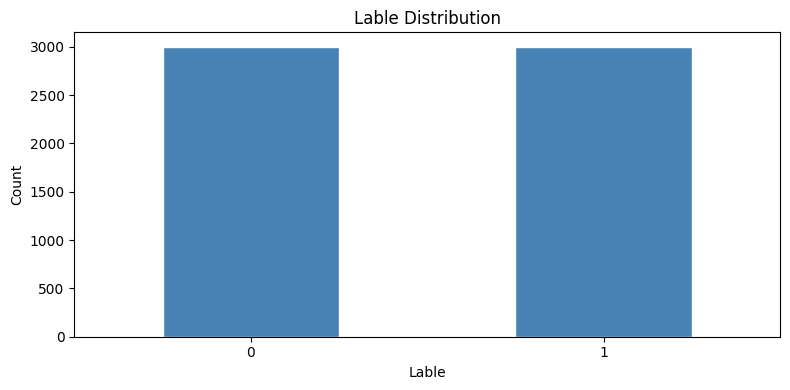

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')

ax.set_title('Lable Distribution')
ax.set_xlabel('Lable')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

In [8]:
df.columns

Index(['duration', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'hot',
       'logged_in', 'num_compromised', 'count', 'srv_count', 'serror_rate',
       'same_srv_rate', 'diff_srv_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate', 'label'],
      dtype='str')

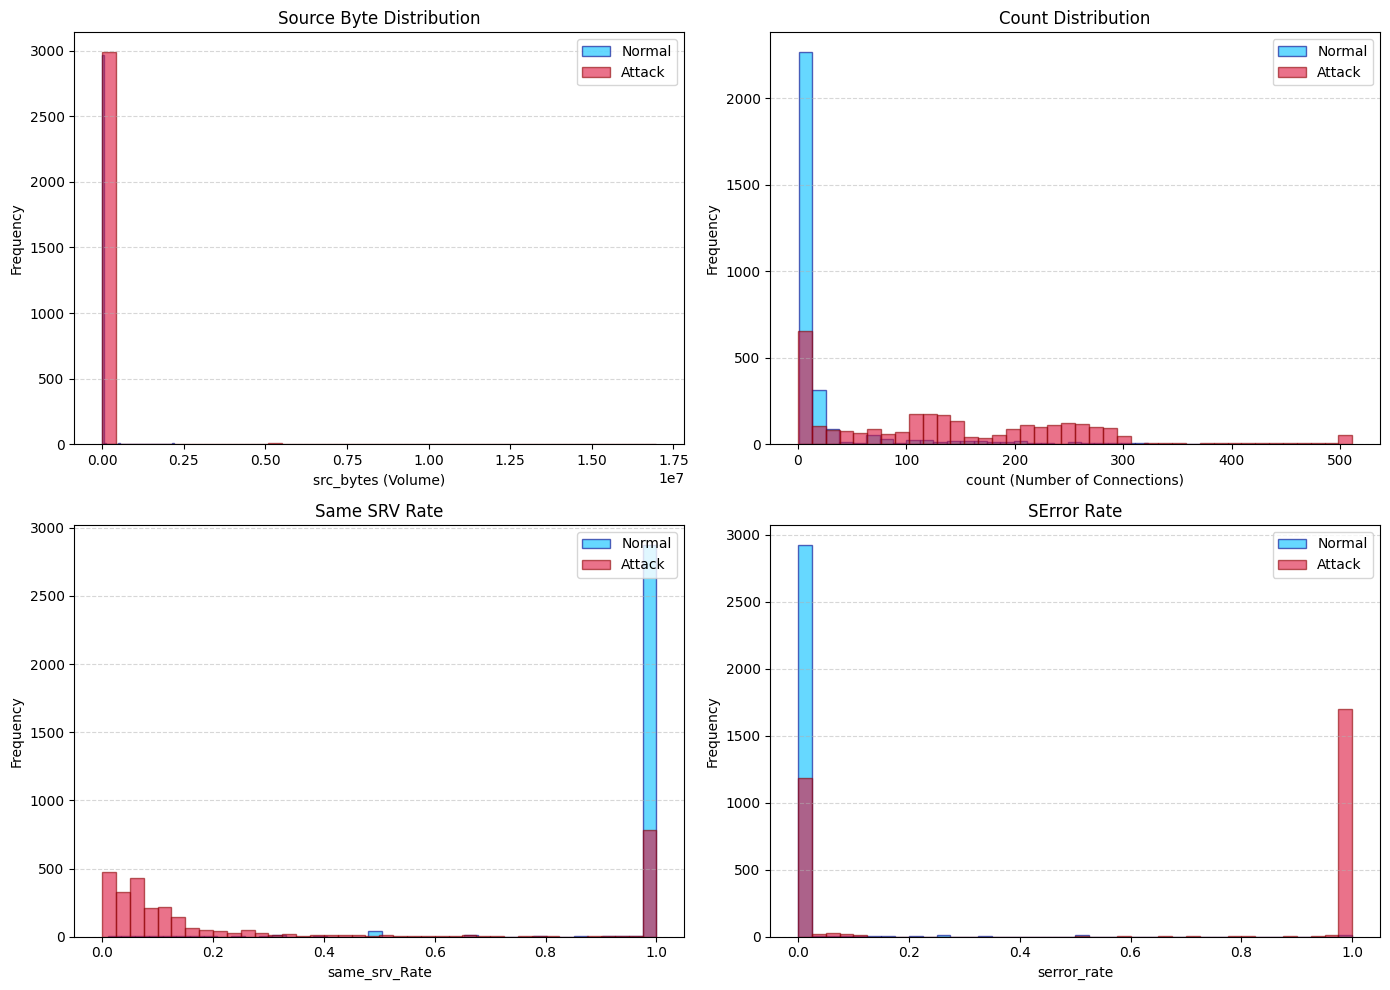

In [9]:
normal_traffic = df[df['label'] == 0]
attack_traffic = df[df['label'] == 1]

alpha_value = 0.6
bins_count = 40

fig, ax = plt.subplots(2, 2, figsize=(14, 10))

ax[0, 0].hist(normal_traffic['src_bytes'], bins=bins_count, alpha=alpha_value, label='Normal', color='deepskyblue', edgecolor='darkblue')
ax[0, 0].hist(attack_traffic['src_bytes'], bins=bins_count, alpha=alpha_value, label='Attack', color='crimson', edgecolor='darkred')

ax[0, 0].set_title('Source Byte Distribution')
ax[0, 0].set_xlabel('src_bytes (Volume)')
ax[0, 0].set_ylabel('Frequency')
ax[0, 0].grid(axis='y', linestyle='--', alpha=0.5)
ax[0, 0].legend(loc='upper right')

ax[0, 1].hist(normal_traffic['count'], bins=bins_count, alpha=alpha_value, label='Normal', color='deepskyblue', edgecolor='darkblue')
ax[0, 1].hist(attack_traffic['count'], bins=bins_count, alpha=alpha_value, label='Attack', color='crimson', edgecolor='darkred')

ax[0, 1].set_title('Count Distribution')
ax[0, 1].set_xlabel('count (Number of Connections)')
ax[0, 1].set_ylabel('Frequency')
ax[0, 1].grid(axis='y', linestyle='--', alpha=0.5)
ax[0, 1].legend(loc='upper right')

ax[1, 0].hist(normal_traffic['same_srv_rate'], bins=bins_count, alpha=alpha_value, label='Normal', color='deepskyblue', edgecolor='darkblue')
ax[1, 0].hist(attack_traffic['same_srv_rate'], bins=bins_count, alpha=alpha_value, label='Attack', color='crimson', edgecolor='darkred')

ax[1, 0].set_title('Same SRV Rate')
ax[1, 0].set_xlabel('same_srv_Rate')
ax[1, 0].set_ylabel('Frequency')
ax[1, 0].grid(axis='y', linestyle='--', alpha=0.5)
ax[1, 0].legend(loc='upper right')

ax[1, 1].hist(normal_traffic['serror_rate'], bins=bins_count, alpha=alpha_value, label='Normal', color='deepskyblue', edgecolor='darkblue')
ax[1, 1].hist(attack_traffic['serror_rate'], bins=bins_count, alpha=alpha_value, label='Attack', color='crimson', edgecolor='darkred')

ax[1, 1].set_title('SError Rate')
ax[1, 1].set_xlabel('serror_rate')
ax[1, 1].set_ylabel('Frequency')
ax[1, 1].grid(axis='y', linestyle='--', alpha=0.5)
ax[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()

# Task 2 — Simple Reflex Agent (rule-based baseline)
A simple reflex agent picks an action based only on the current percept using if–then rules. Build such an agent as a baseline classifier:

- Look at the histograms from Task 1 and choose two or three features that seem to separate the classes (for example serror_rate, same_srv_rate, count).
- Write a Python function reflex_agent(row) that returns 0 or 1 using a small set of hand-picked thresholds, e.g.
if serror_rate > 0.5 then 1, else 0.
- Apply the agent to the whole dataset and report accuracy and the confusion matrix.
- In a short paragraph in your report, explain why this is an example of a simple reflex agent (percept → rule → action, no internal state).

In [10]:
def reflex_agent(connection):
    if connection.same_srv_rate < 0.4:
        return 0
    elif connection.serror_rate > 0.5:
        return 0
    elif connection.count > 100:
        return 0
        
    return 1

In [11]:
normal_count = 0
attack_count = 0

for connection in df.itertuples(index=True):
    if reflex_agent(connection):
        normal_count += 1
    else:
        attack_count += 1

print("Normal vs Attack traffic using Reflex Agent")
print(f"Total Normal Connections: {normal_count}")
print(f"Total Attack Connections: {attack_count}")


Normal vs Attack traffic using Reflex Agent
Total Normal Connections: 3371
Total Attack Connections: 2629


In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

predictions = []
for connection in df.itertuples(index=True):
    predictions.append(reflex_agent(connection))

actual_labels = df['label'].tolist()

accuracy = accuracy_score(actual_labels, predictions)
print(f"Accuracy of Reflex Agent: {accuracy:.4f} ({accuracy * 100:.2f}%)")
print()

Accuracy of Reflex Agent: 0.1585 (15.85%)



In [13]:
cm = confusion_matrix(actual_labels, predictions)
print("Confusion Matrix:")
print(cm)
print()

print("Confusion Matrix (with labels):")
print("                Predicted: Normal  Predicted: Attack")
print(f"Actual: Normal       {cm[0, 0]:>6}         {cm[0, 1]:>6}")
print(f"Actual: Attack       {cm[1, 0]:>6}         {cm[1, 1]:>6}")
print()

print("Classification Report:")
print(classification_report(actual_labels, predictions, target_names=['Normal (0)', 'Attack (1)']))

Confusion Matrix:
[[ 290 2710]
 [2339  661]]

Confusion Matrix (with labels):
                Predicted: Normal  Predicted: Attack
Actual: Normal          290           2710
Actual: Attack         2339            661

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.11      0.10      0.10      3000
  Attack (1)       0.20      0.22      0.21      3000

    accuracy                           0.16      6000
   macro avg       0.15      0.16      0.16      6000
weighted avg       0.15      0.16      0.16      6000



# TASK 3 — Supervised Learning

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")
print(f"Training set label distribution:\n{y_train.value_counts()}")
print(f"\nTest set label distribution:\n{y_test.value_counts()}")

Training set size: 4800
Test set size: 1200
Features: 15
Training set label distribution:
label
0    2400
1    2400
Name: count, dtype: int64

Test set label distribution:
label
0    600
1    600
Name: count, dtype: int64


In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

k_values = [1, 3, 5, 7, 9, 11]
knn_accuracies = []
knn_models = {}

print("K-Nearest Neighbors")

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred_knn)
    knn_accuracies.append(accuracy)
    knn_models[k] = knn
    print(f"k ={k:2d}: Test Accuracy = {accuracy:.4f} ({accuracy*100:.2f}%)")

best_k = k_values[knn_accuracies.index(max(knn_accuracies))]
best_knn_accuracy = max(knn_accuracies)
print(f"Best k: {best_k} with accuracy {best_knn_accuracy:.4f} ({best_knn_accuracy*100:.2f}%)")

K-Nearest Neighbors
k = 1: Test Accuracy = 0.9767 (97.67%)
k = 3: Test Accuracy = 0.9758 (97.58%)
k = 5: Test Accuracy = 0.9767 (97.67%)
k = 7: Test Accuracy = 0.9708 (97.08%)
k = 9: Test Accuracy = 0.9675 (96.75%)
k =11: Test Accuracy = 0.9658 (96.58%)
Best k: 1 with accuracy 0.9767 (97.67%)


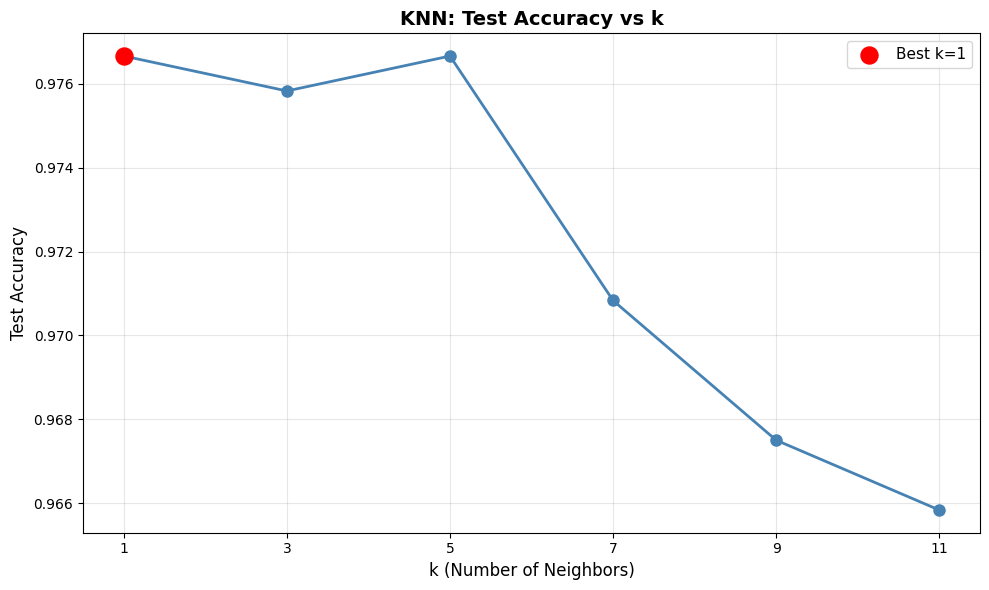

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_values, knn_accuracies, marker='o', linestyle='-', linewidth=2, markersize=8, color='steelblue')
ax.scatter([best_k], [best_knn_accuracy], color='red', s=150, zorder=5, label=f'Best k={best_k}')
ax.set_xlabel('k (Number of Neighbors)', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('KNN: Test Accuracy vs k', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xticks(k_values)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [17]:
from sklearn.naive_bayes import GaussianNB

print("Naive Bayes Classifier (GaussianNB)")

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
cm_nb = confusion_matrix(y_test, y_pred_nb)

print(f"\nTest Accuracy: {accuracy_nb:.4f} ({accuracy_nb*100:.2f}%)")
print(f"\nConfusion Matrix:")
print(cm_nb)
print(f"\nConfusion Matrix (with labels):")
print("Predicted: Normal  Predicted: Attack")
print(f"Actual: Normal       {cm_nb[0, 0]}         {cm_nb[0, 1]}")
print(f"Actual: Attack       {cm_nb[1, 0]}         {cm_nb[1, 1]}")
print(f"\nClassification Report")
print(classification_report(y_test, y_pred_nb, target_names=['Normal (0)', 'Attack (1)']))

Naive Bayes Classifier (GaussianNB)

Test Accuracy: 0.7875 (78.75%)

Confusion Matrix:
[[575  25]
 [230 370]]

Confusion Matrix (with labels):
Predicted: Normal  Predicted: Attack
Actual: Normal       575         25
Actual: Attack       230         370

Classification Report
              precision    recall  f1-score   support

  Normal (0)       0.71      0.96      0.82       600
  Attack (1)       0.94      0.62      0.74       600

    accuracy                           0.79      1200
   macro avg       0.83      0.79      0.78      1200
weighted avg       0.83      0.79      0.78      1200



In [18]:
from sklearn.linear_model import LogisticRegression

print("Logistic Regression Classifier")

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(f"\nTest Accuracy: {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")
print(f"\nConfusion Matrix:")
print("                Predicted: Normal  Predicted: Attack")
print(f"Actual: Normal       {cm_lr[0, 0]}             {cm_lr[0, 1]}")
print(f"Actual: Attack       {cm_lr[1, 0]}             {cm_lr[1, 1]}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Normal (0)', 'Attack (1)']))

Logistic Regression Classifier

Test Accuracy: 0.8683 (86.83%)

Confusion Matrix:
                Predicted: Normal  Predicted: Attack
Actual: Normal       553             47
Actual: Attack       111             489

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.83      0.92      0.88       600
  Attack (1)       0.91      0.81      0.86       600

    accuracy                           0.87      1200
   macro avg       0.87      0.87      0.87      1200
weighted avg       0.87      0.87      0.87      1200



/media/rauf/Data/education/BSCS/semester-04/AI-lab/project/nids/venvNIDS/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
print("Summary of Comparison")

best_knn = knn_models[best_k]
y_pred_best_knn = best_knn.predict(X_test)
cm_best_knn = confusion_matrix(y_test, y_pred_best_knn)

comparison_data = {
    'Classifier': [f'KNN (k={best_k})', 'Naïve Bayes', 'Logistic Regression'],
    'Test Accuracy': [best_knn_accuracy, accuracy_nb, accuracy_lr],
    'Accuracy %': [f'{best_knn_accuracy*100:.2f}%', f'{accuracy_nb*100:.2f}%', f'{accuracy_lr*100:.2f}%']
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string())

print(f"\nBest classifier: {comparison_data['Classifier'][comparison_data['Test Accuracy'].index(max(comparison_data['Test Accuracy']))]}")
print(f"Best accuracy: {max(comparison_data['Test Accuracy']):.4f} ({max(comparison_data['Test Accuracy'])*100:.2f}%)")

Summary of Comparison
            Classifier  Test Accuracy Accuracy %
0            KNN (k=1)       0.976667     97.67%
1          Naïve Bayes       0.787500     78.75%
2  Logistic Regression       0.868333     86.83%

Best classifier: KNN (k=1)
Best accuracy: 0.9767 (97.67%)


# Task 4 — Clustering with K-Means

Confusion Matrix between labels and cluster IDs:
[[2847  153]
 [ 627 2373]]


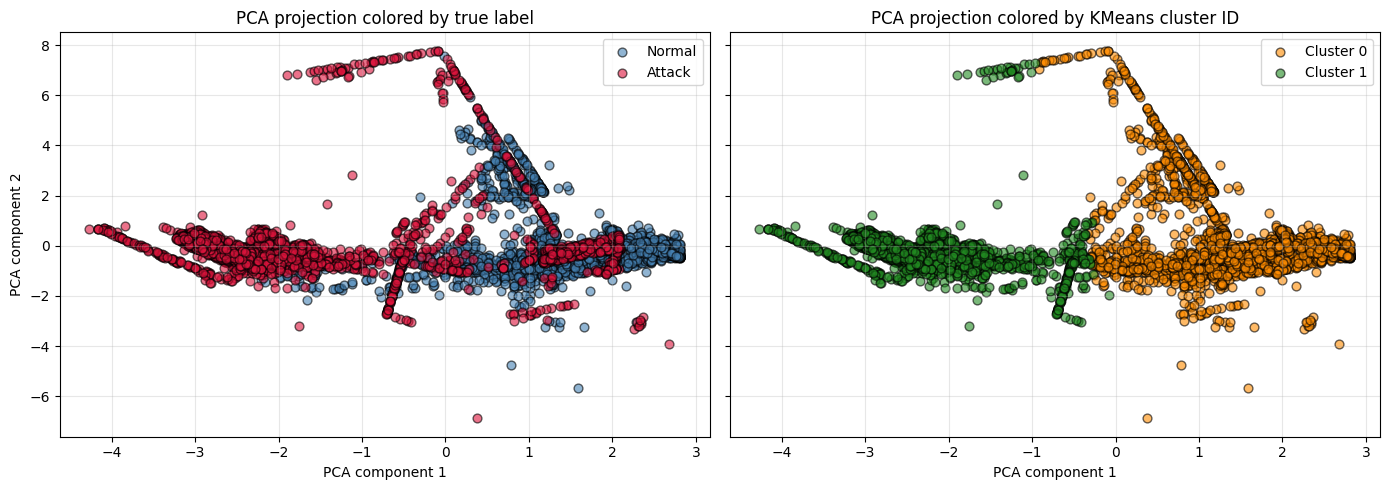

In [20]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

X_unlabeled = df.drop('label', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unlabeled)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_ids = kmeans.fit_predict(X_scaled)

cm_clusters = confusion_matrix(df['label'], cluster_ids)
print('Confusion Matrix between labels and cluster IDs:')
print(cm_clusters)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

label_names = {0: 'Normal', 1: 'Attack'}
label_colors = {0: 'steelblue', 1: 'crimson'}
cluster_colors = {0: 'darkorange', 1: 'forestgreen'}

for label in [0, 1]:
    mask = df['label'] == label
    axes[0].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=label_colors[label], label=label_names[label], alpha=0.6, edgecolor='k', s=40
    )

axes[0].set_title('PCA projection colored by true label')
axes[0].set_xlabel('PCA component 1')
axes[0].set_ylabel('PCA component 2')
axes[0].legend()
axes[0].grid(alpha=0.3)

for cluster in [0, 1]:
    mask = cluster_ids == cluster
    axes[1].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=cluster_colors[cluster], label=f'Cluster {cluster}', alpha=0.6, edgecolor='k', s=40
    )

axes[1].set_title('PCA projection colored by KMeans cluster ID')
axes[1].set_xlabel('PCA component 1')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Task 5 — Genetic Algorithm for Feature Selection

In [21]:
import random
from sklearn.linear_model import LogisticRegression

feature_names = X_train.columns.tolist()
num_features = len(feature_names)
population_size = 10
generations = 10
mutation_rate = 0.1
crossover_rate = 0.8
random.seed(42)

def create_chromosome():
    chromosome = [random.choice([0, 1]) for _ in range(num_features)]
    if sum(chromosome) == 0:
        chromosome[random.randrange(num_features)] = 1
    return chromosome

def fitness(chromosome):
    selected = [i for i, bit in enumerate(chromosome) if bit]
    if not selected:
        return 0.0
    model = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')
    model.fit(X_train.iloc[:, selected], y_train)
    return accuracy_score(y_test, model.predict(X_test.iloc[:, selected]))

def select_parent(fitnesses, k=3):
    candidates = random.sample(range(population_size), k)
    return population[max(candidates, key=lambda idx: fitnesses[idx])]

def crossover(parent1, parent2):
    if random.random() > crossover_rate:
        return parent1[:], parent2[:]
    point = random.randrange(1, num_features)
    return parent1[:point] + parent2[point:], parent2[:point] + parent1[point:]

def mutate(chromosome):
    child = chromosome[:]
    for i in range(num_features):
        if random.random() < mutation_rate:
            child[i] = 1 - child[i]
    if sum(child) == 0:
        child[random.randrange(num_features)] = 1
    return child


population = [create_chromosome() for _ in range(population_size)]

for generation in range(1, generations + 1):
    fitnesses = [fitness(chrom) for chrom in population]
    best_idx = max(range(population_size), key=lambda idx: fitnesses[idx])
    best_chrom = population[best_idx]
    best_score = fitnesses[best_idx]
    print(f"Generation {generation}: best accuracy = {best_score:.4f}, selected features = {sum(best_chrom)}")

    new_population = [best_chrom[:]]  # elitism
    while len(new_population) < population_size:
        parent1 = select_parent(fitnesses)
        parent2 = select_parent(fitnesses)
        child1, child2 = crossover(parent1, parent2)
        new_population.append(mutate(child1))
        if len(new_population) < population_size:
            new_population.append(mutate(child2))
    population = new_population

fitnesses = [fitness(chrom) for chrom in population]
best_idx = max(range(population_size), key=lambda idx: fitnesses[idx])
best_chrom = population[best_idx]
selected_features = [name for name, bit in zip(feature_names, best_chrom) if bit]
print('\nBest chromosome:')
print(best_chrom)
print('Selected features:', selected_features)
print(f'Best test accuracy: {fitnesses[best_idx]:.4f}')

Generation 1: best accuracy = 0.8892, selected features = 7
Generation 2: best accuracy = 0.8950, selected features = 6
Generation 3: best accuracy = 0.8950, selected features = 6
Generation 4: best accuracy = 0.8950, selected features = 6
Generation 5: best accuracy = 0.8958, selected features = 8
Generation 6: best accuracy = 0.8958, selected features = 8
Generation 7: best accuracy = 0.9050, selected features = 9
Generation 8: best accuracy = 0.9050, selected features = 9
Generation 9: best accuracy = 0.9058, selected features = 7
Generation 10: best accuracy = 0.9058, selected features = 7

Best chromosome:
[1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1]
Selected features: ['duration', 'wrong_fragment', 'srv_count', 'serror_rate', 'same_srv_rate', 'dst_host_srv_count', 'dst_host_same_srv_rate']
Best test accuracy: 0.9058
